# 24 · GPU math is not the wall clock — RISC0 Groth16 bottleneck forensics

This lab records an engineering experience that matters more than a "successful speedup": **BN254 MSM/NTT already runs correctly on the Radeon 8060S (`gfx1151`) iGPU, but the complete Groth16 receipt did not get faster.**

Committed benchmark (3 solo reps, every receipt checked by the stock verifier):

- CPU end-to-end median: **182.37 s**
- ROCm end-to-end median: **187.44 s**
- GPU/CPU speed ratio: **0.973×** (GPU is about 2.7% slower)
- GPU gnark BN254 prove: **about 8.9 s**

**W0 measured that residual, and the result refuted the original assumption — twice.**

## W0 investigation log

### First refutation: witness is not the bottleneck

2026-07-29, production FIFO, 3 solo reps (every receipt checked by the stock verifier):

| stage | median | share of full pipeline |
|---|---:|---:|
| Circom `stark_verify` witness (CPU) | 1.718 s | 0.8% |
| Groth16 container stages, total | 11.130 s | 5.3% |
| before the container (rv32im STARK + recursion + identity_p254) | 199.462 s | **94.7%** |
| r0vm full pipeline | 210.592 s | 100% |

### Second refutation: the cause of 0.973× is that the ROCm prover itself is slower

Same image, same archived seal, same FIFO, switching only `RISC0_GROTH16_ACCELERATOR`:

| config | accelerator | container total |
|---|---|---:|
| `cpu-witness` | **CPU gnark** | **5.764 s** |
| `rocm-witness` | ROCm gnark | 11.102 s |

**ROCm is 5.338 s slower than CPU (CPU/ROCm = 0.519×).** Compare the earlier end-to-end gap of
**+5.07 s** between CPU 182.37 s and ROCm 187.44 s — the two agree. **0.973× is fully explained by this
one item, and has nothing to do with witness.**

### The real ceiling for witness: measured, not inferred

`rocm-replay` feeds a pre-generated `.wtns` through **exactly the same FIFO**, removing only the witness computation:

| config | container total |
|---|---:|
| `rocm-witness` (witness actually computed) | 11.102 s |
| `rocm-replay` (pre-generated witness) | 10.340 s |

**Measured saving: 0.762 s**, i.e. **0.36%** of the pipeline. That is the ceiling for a perfect witness backend.

> Three framings must not be mixed: **share** (fifo) 0.82% / **serialized upper bound** (file) 0.86% /
> **critical-path contribution** (fifo, production) **0.36%**. Only the last one answers "is it worth doing".
> 
> ⚠️ **Which rep set the container totals use.** Every figure in this section and in the accelerator table
> above it — 11.102, 10.340, 5.764 — is the median over **reps 1–3** of the four in `container-compare.csv`,
> rep 0 being dropped as warm-up, the same convention flagged for 11.004 and for the binned rows further
> down. Recompute across all four reps and you get 11.098, 10.346 and 5.750 instead, which moves the witness
> saving to 0.752 s (still 0.36% of the pipeline) and the CPU-versus-ROCm gap to 5.349 s, or 0.518×. Neither
> choice changes a conclusion here, but it does decide the last decimal, so match the rep set before
> comparing anything against these.

### Third correction: the default parameters are a bug, and the root cause is the algorithm, not the hardware

Tuning two environment variables — `RISC0_GROTH16_ROCM_WINDOW_MAX=8` and
`RISC0_GROTH16_ROCM_WORK_UNITS=10240` — takes the container from **11.057 s down to 7.437 s**
(**−3.620 s, 1.49×**), session-paired, with **< 0.7%** variation across 8 runs.

> **2026-08-06 correction (reproduced and decomposed by measurement)**: the 1.49× holds — remeasured at **1.490×** —
> but it is the **product of two things**, and one of them is now built in:
> 
> | setting | container total | cumulative |
> |---|---|---|
> | nothing set | 11.004 s | — |
> | +`WORK_UNITS=10240` | 7.706 s | **1.428×** |
> | +`WINDOW_MAX=8` | 7.385 s | **1.490×** |
> 
> After `d622c88` the default in `schedule.go` is `512 × CU`, which on this 20 CU machine is exactly 10240,
> so **you now get the work_units half without setting anything**; but **`WINDOW_MAX=8` is still worth 4.3%, so keep setting it**.
> Four rounds each, and the two ranges do not overlap (`[7.684, 7.738]` vs `[7.319, 7.419]`).
> The CU count itself is not an assumption: it is the `compute_units` column of
> `msm-work-units-per-cu.csv`, whose single `gfx1151` row carries it alongside the matching `per_cu` and
> `work_units` values. The two default work-unit formulas — the one here and the workgroup-width one quoted
> further down — are therefore arithmetic on that column, not separate measurements.
> 
> ⚠️ **How to reproduce the figures in this section.** Two bundles are in play and neither headline number is
> a plain median. The 11.057 → 7.437 pair at the top comes from
> `groth16-tuning-ab-gfx1151-20260730T052934Z/tuning-ab.csv`, whose `provenance.txt` carries the image digest
> those eight runs share, and both values are that arm's **single rep-3 `container_s`** rather than a median —
> which is what makes the gap land on exactly −3.620 s. Taking the four-rep median of each arm instead gives
> 11.066 s and 7.449 s, a gap of **−3.617 s**, still 1.49× either way. For the table just above, recomputing
> the four-rep median at full precision from the committed `container-compare.csv` gives
> **10.977 / 7.705 / 7.384**, so expect that CSV to disagree with its point values in the last decimals too;
> and those three were not produced by one consistent rule either: 7.706 and 7.385 reproduce as the median
> over rep values already rounded to three decimals, while 11.004 reproduces as the median over reps 1–3
> rather than over all four.
> 
> ⚠️ **The container measures the code in the image, not the code in the working tree**: the set above ran on an image built on 07-29,
> 28 hours before `d622c88` (07-30 14:59Z). Before quoting any container A/B, check the image build time first.

Reading the kernel source is what revealed the real cause. `bn254_g1_kernel.hpp` describes itself as a
port that is `bit-for-bit identical to the OpenCL path`; compared against gnark's production-grade CPU MSM, it lacks:

- **signed-digit recoding** → twice as many buckets (`(1u << window_size) - 1`)
- **batch affine addition** → every bucket addition uses `g1_add_mixed` (madd-2007-bl) at about 11 muls,
  whereas batch affine amortizes the inversion down to about 5–6 muls
- every thread keeps its own bucket array in global memory, **serially zeroed before work starts**:
  `work_units × (2^w − 1) × 96 B`, which is **1,006 MB** at w10 and **251 MB** at w8

So the correct statement is **"this ec-gpu-lineage ported kernel is slower than gnark's production-tuned
CPU MSM"**, and **not** "AMD GPUs are slower at MSM". Both optimizations are standard practice and are **fixable**.

### Fourth correction: the hardware is actually faster, and the ISA hypothesis was refuted by measurement

"The GPU is slow because 256-bit modular multiplication is inherently disadvantaged on the GPU ISA" sounds
plausible — x86 has `MULX` plus two independent carry chains, while RDNA has to emulate them through VCC.
This hypothesis **can be measured directly**, so we measured it.

Strip out all point arithmetic, buckets and scatter, and measure bare Montgomery multiplication only:

| | throughput | per multiplication |
|---|---:|---:|
| 1× R9700 | **11.63 G muls/s** | 0.086 ns |
| full 64C/128T CPU | 4.83 G muls/s | 0.207 ns |

**The GPU is 2.41× faster. The ISA hypothesis is dead.**

The CPU baseline uses gnark's own `fr` — the very path that wins Groth16, not a deliberately
limb-by-limb reference implementation (which would have handed the GPU several orders of magnitude for
free). Both sides use chained multiplication with tunable ILP; otherwise an out-of-order CPU measures
latency instead of throughput, understating the CPU by 1.4×.

The intensity curve also gives direct evidence on the memory hypothesis:

```
chain=1   → 6.21 G muls/s   ← ceiling allowed by pure memory traffic (53% of ALU)
chain≥16  → 11.6 G (flat)   ← ALU ceiling
```

At low arithmetic intensity the GPU delivers only half of its capability — **and bucket accumulation is exactly that low-intensity, high-traffic pattern**.

Put the two together: on that host the hardware is 2.41× faster and Groth16 is 2.33× slower → this MSM
implementation **leaves roughly 5.6× of the hardware's capability unrealized**. (An estimate, assuming Groth16 time scales proportionally with field throughput.)

> **Methodology lesson**: for "the GPU is slower" we guessed a bandwidth problem, then an ISA problem, and
> got the direction wrong once along the way. In the end **reading the source** found the algorithmic deficit,
> and **one targeted microbenchmark** executed the ISA hypothesis.
> **Read the implementation before discussing architecture; design hypotheses so a single experiment can kill them.**


### Converting "slower" into core count: this iGPU is worth 11 threads

"1.29× slower than the CPU" depends on which CPU is in the box. Throttling the CPU arm down until it meets
the accelerator yields a quantity that is independent of the opponent. Against the tuned iGPU prover (**5221.7 ms**):

| threads | prove | speedup vs 2 threads | parallel efficiency |
|---:|---:|---:|---:|
| 2 | 22009.2 ms | 1.00× | 100.0% |
| 4 | 11890.5 ms | 1.85× | 92.5% |
| 8 | 6645.4 ms | 3.31× | 82.8% |
| 12 | 4793.0 ms | 4.59× | 76.5% |
| 16 | 3824.6 ms | 5.75× | 71.9% |
| 24 | 3689.2 ms | 5.97× | 49.7% |
| 32 | 3534.0 ms | 6.23× | **38.9%** |

**The crossover is at about 11.1 / 32 threads**, roughly 5.5 physical cores.

The shape of the curve carries more information than the crossover point: **gnark saturates at the 16-core
SMT boundary**, and the last thread doubling (16→32) buys only **8.2%**.

> So the iGPU is not losing to a linearly scaling 32-thread CPU; it is losing to a CPU that is **already saturated**.
> This also explains why a 64-core host reports a worse ratio for the same silicon.
> 
> ⚠️ **Reproducing the two sides of this comparison.** The thread rows are each the median over every
> `GOMAXPROCS` row at that count in `cpu-scaling.csv`, which is four rows for 4 threads and three for the
> rest. The 5221.7 ms reference is not a median: it is the single `confirm` rep 5 of
> `groth16-power-gfx1151-20260731T011902Z/tuned/rocm-tuning.csv`, whose `provenance.txt` records the image
> and seal hashes; those six rows median to **5219.7 ms** pooled, or **5217.7 ms** across the five `confirm`
> reps. All three land the crossover at 11.1 threads, so the headline figure does not depend on the choice.

Together with the energy section below: **it does the work of 11 threads at 0.87× the socket power.**

### The two machines are not on the same scaling curve

It briefly looked like a match: parallel efficiency at 32 threads was 38.9% on one machine and 38.3% on the
other, half a percentage point apart. **That was an artefact** — 38.9% is normalized to 2 threads and 38.3% to 4 threads. On a common 4-thread baseline:

| threads | gfx1151 (16C/32T) | gfx1201 host (64C/128T) | delta |
|---:|---:|---:|---:|
| 4 | 100.0% | 100.0% | +0.0 |
| 8 | 89.5% | 80.9% | +8.6 |
| **16** | **77.7%** | **57.5%** | **+20.2** |
| 32 | 42.1% | 38.3% | +3.8 |

**The middle of the range differs by 20.2 percentage points; the two curves merely cross near 32 threads.**
The cause of saturation also differs: 16 threads is the physical core limit on my machine, but only 1/4 of the cores on the other.

> A constant that looks portable across machines has to be renormalized to a common baseline before it is
> quoted — **two efficiency numbers are comparable only when the denominator is the same.**

### Watts cannot be tabulated across machines

On this APU, `amdgpu power1_average` is **socket-wide** (verified: the CPU arm draws 63.11 W while GPU
utilization reads 0%, against 9.47 W at idle). But **on a discrete card the same sysfs node reports board power only**,
with no CPU package at all.

**So the joule figures in this document apply to the APU only**; putting them in the same table as joule
figures from a discrete-GPU host would be wrong, no matter how carefully each side was measured.

### Add runtime GPU evidence, and verify that it blocks

The earlier sweep and container-compare recorded only the **pre-launch** idle check, with nothing watching
during the run — a run that claims ROCm but never touches the GPU would still be recorded.

Both now call `solo_guard_watch_start`/`_stop` and fail closed:

```
ROCm arm  peak GPU must be > ZKP_RUNTIME_MIN_GPU_PCT (default 20%)
CPU  arm  peak GPU must not exceed the idle ceiling (contamination check)
both      the lock must not be stolen, and the watch must produce samples
```

**Verified in both directions, not assumed:**

```
threshold set to an impossible 200%  →  exit 1, 0 rows written, "peak GPU use 83% below 200%"
default threshold 20%                →  exit 0, CSV records peak_gpu=83% samples=4
                                        stolen=false max_power=69–77W min_sclk=600MHz
```

The point of this section is not that a check was added, but that **the failure case was confirmed to
actually fail** — a guard that prints green without blocking anything is more dangerous than no guard.

### Confirm the knob before sweeping it

The most intuitive variable for this sweep, `RAYON_NUM_THREADS`, moves the CPU arm of this container by
only **+0.03%** — that is, not at all. The Groth16 prover here is **gnark, a Go binary** (`go1.23.12`), so
the control is `GOMAXPROCS`; Rayon governs a different stage.

**Sweeping blindly on intuition would produce a flat line across every thread count, and that flat line would be misread as a property of the hardware.**

### Energy: the iGPU draws less power and still loses

Sampled from sysfs at 9.1 Hz in sync with the run (median):

| setting | time | power | energy/proof |
|---|---:|---:|---:|
| CPU | 5.749 s | 63.11 W | **362.5 J** |
| ROCm default | — | — | 539.0 J |
| **ROCm tuned w8/u10240** | 7.432 s | 54.90 W | **408.0 J** |

> **Where this table comes from, and what you can recheck.** The power and energy figures in and around this
> table — 63.11 W, 54.90 W, 9.47 W, 362.5 J, 408.0 J, 539.0 J, the 130.9 J / 24.3% tuning saving, the 9.1 Hz
> sampling rate and the CPU time of 5.749 s — are the author's own measurements. The per-point power
> telemetry behind them does not ship in this bundle, so **the watt and joule values cannot be recomputed
> from anything here**, and the derived 0.87×, 1.13× and 1.29× inherit that limit. One figure is independently
> checkable: the tuned ROCm time of 7.432 s is the median over the five `confirm` reps of `total_s` in
> `groth16-power-gfx1151-20260731T011902Z/tuned/rocm-tuning.csv`, a file that carries timing columns only.
> 
> Note also that the 5.749 s above and the 5.750 s in the rep-set note earlier are **different measurements,
> not two spellings of one number**: this one is the CPU arm of the power run, that one the four-rep median
> of `cpu-witness` in `container-compare.csv`. And the two dashed cells stay dashed because the ROCm default
> row's time and power, and the per-row intervals this table used to carry, have no file here at all — the
> script that integrates power into joules is not in this repo, so they are omitted rather than restated
> without a checkable source.

**The iGPU draws 0.87× the power, converting a 1.29× time disadvantage into a 1.13× energy disadvantage.**
Still a disadvantage — the tuned iGPU's energy per proof stays above the CPU's. Tuning by itself saves **130.9 J (24.3%)**.

> **The sensor scope is verified, not assumed.** The CPU arm draws 63.11 W while `gpu_busy_percent` reads 0,
> against only 9.47 W at idle — so on this APU `amdgpu power1_average` is **socket-wide**, and both arms are
> measured on the same basis.

### Two checks on the evidence itself

**The GPU probe was not broken; what was broken is that nobody watched during the run.** Every artefact in
this repo records `gpu_pct=0`, which looks like a sensor fault but is not: the same probe reads a
**99% peak and 59.9% average** on the ROCm arm, and **0%** on the CPU arm. That 0 is the **pre-launch idle check**, and it is semantically correct.

The real problem lies elsewhere: `solo_guard_watch_start` (the runtime watch I added for this) **is called by only one runner**,
and neither the sweep nor container-compare — the two that produced the headline numbers — calls it.
**A guard that is written but not installed on the paths that matter is not a guard.**

**Correctness coverage did not follow the numbers.**

```
run-groth16-tuning-ab.sh          cargo risczero verify, 8/8, fail-closed  ✅
run-groth16-rocm-tuning-sweep.sh  no verification                          ❌
run-groth16-container-compare.sh  no verification                          ❌
```

> **Correction (2026-08-03)**: this section previously said "the image has the proving key but no verification key,
> and `proof.json` has no public signals, **so verification is structurally impossible**". The first two clauses are right; **the conclusion is wrong**.
>
> ```
> zkey.go:237   func ReadZKey(...) (ProvingKey, VerifyingKey, error)
> converter:104 pk, _, err := circom.ReadZKey(file, cs)   ← vk is discarded
> prover:39     <output proof> [output public]            ← supported all along
> prover.sh     passes only up to the 4th argument
> ```
>
> **The vk was in the zkey all along and the public output has always been a supported flag; nobody wired it up.**
> "Cannot" would be a limitation of Groth16 or of the seam; "did not" is our omission —
> and I inferred an "impossible" from two "absences" while writing this very section on verification discipline,
> without reading the source that produced the absence.

So the per-CU rule, the window comparison and the energy numbers above are all **timing-only evidence**;
the A/B path is the one with correctness backing. This section now says which is which.

### The shipped default is four times too small, and what transfers is the "ratio"

The shipped work_units default is `localWorkSize × computeUnits` — **one work unit per lane**. That is a
reasonable initial guess, but it appears nobody ever measured it.

Three sweeps across two architectures all put the optimum at **512 work units per compute unit**:

| source | work_units | CU | per-CU |
|---|---:|---:|---:|
| gfx1201 standalone | 16384 | 32 | 512 |
| gfx1201 container | 16384 | 32 | 512 |
| **gfx1151 container (this repo)** | **10240** | **20** | **512** |

gfx1201 container sweep (window≤9, prover stage, median of three reps):

| per-CU | prover | vs CPU |
|---:|---:|---:|
| 128 (shipped default) | 7020.4 ms | 4.18× |
| 256 | 4398.1 ms | 2.64× |
| **512** | **3145.1 ms** | **1.87×** |
| 1024 | 3348.4 ms | 2.01× |

**The default costs 2.23×.**

The fix encodes a **rule rather than a constant** — `workUnitsPerComputeUnit = 512` plus
`defaultWorkUnits(computeUnits)`, placed in `schedule.go`, the file that advertises itself as "testable without a GPU".

> **Unverified**: devices with a CU count high enough that 512/CU blows out memory. Neither card hit that boundary.

### What transfers is the tuning, not the implementation

This is the most reusable sentence in the whole investigation:

```
per-CU ratio       ✅ holds on both architectures (512)
best window        ❌ 9 on gfx1201, 8 on gfx1151
binned's 1.45×     ❌ did not transfer at all
```

I originally wrote it as "tuning transfers, implementations do not" — **ten minutes of follow-up sweeping
refuted that sentence**. Filling in w=9 on gfx1151 gives 5284.9 ms, still behind w=8 at 5228.3 ms (5 runs
each, non-overlapping ranges, 25/25 pairings). The gap is only 1.1%, but the direction is unambiguous.

And that direction is **explainable**: window size determines bucket memory
(`work_units × (2^w − 1) × 96 B`), and a unified-memory APU has far less bandwidth than a discrete card,
so it prefers a smaller window.

> So the correct statement is narrower than the tempting one: **parameters that describe device geometry
> transferred, parameters that trade memory for pass count did not, and the kernel rewrite transferred nothing at all.**

The follow-up sweep also confirms that 512/CU is a **true peak** rather than the edge of a coarse grid:
384/CU 5777.1 ms, 512/CU 5228.3 ms, 768/CU 5417.4 ms.

> ⚠️ **How to reproduce every `rocm-tuning.csv` figure in this section.** That bundle runs in two phases —
> a `coarse` grid scan and a three-rep `confirm` pass — and the prove figures quoted above are medians
> over **both phases pooled**, whereas `summary.json`/`summary.md` report the **confirm-only** median. The
> two agree at 512/CU, which is 5228.3 either way, and diverge elsewhere: 768/CU is 5417.4 pooled against
> **5421.5** confirm-only, and w=9 at 512/CU is 5284.9 pooled against **5277.6** confirm-only. So a reader
> recomputing from `summary.md` alone will not land on the pooled figures, and neither set is wrong — they
> answer different questions.
>
> The three per-CU points also mix window sizes: 384/CU is the one taken at `w=9, u=7680`, where the CSV
> has no `confirm` rows at all, so its 5777.1 is a two-rep coarse median; 512/CU and 768/CU come from
> `w=8`. Read that group as a coarse check that 512/CU is not a grid edge, not as a controlled per-CU
> sweep at a fixed window.

### Methodology correction: comparing accelerators rules out container total time

Container total time contains **shared cost that has nothing to do with the accelerator** — loading the
constraint system, the proving key and the witness, then solving the constraint system. Median of four reps:

```
                CPU arm     ROCm arm
constraint sys   312.1 ms    313.2 ms
proving key      548.4 ms    540.5 ms
witness data     992.2 ms    993.5 ms
solver           138.3 ms    144.5 ms
─────────────────────────────────────
shared cost     1991.0 ms   1991.7 ms   ← 0.7 ms apart (0.04%)
prover stage    3508.1 ms   8839.4 ms   ← this is the accelerator
```

About 2 seconds of shared cost is counted into the total time of both arms, **diluting the ratio towards 1**. Switching to the prover stage:

| | container level | **prover stage** |
|---|---:|---:|
| untuned gap | 1.94× | **2.52×** |
| tuned gap | 1.31× | **1.49×** |
| speedup from tuning itself | 1.48× | **1.69×** |

**Note that all three numbers change, and that the tuning result is revised upwards** (1.48× → 1.69×).
Every externally quoted accelerator ratio in this repo now uses the prover stage.

### The ceiling: MSM is 82.9%, and that bounds the whole roadmap

Per-stage timing inside the FFI on gfx1201 (three reps, same seal, median):

| stage | time | share | calls |
|---|---:|---:|---:|
| `msm_g1` | 3351.5 ms | 50.2% | 4 |
| `msm_g2` | 2182.1 ms | 32.7% | 1 |
| `ntt` | 436.3 ms | 6.5% | 6 |
| outside the library | 706.4 ms | 10.6% | — |
| **ROCm prover** | **6676.2 ms** | | |
| **CPU prover** | **1674.0 ms** | | |

MSM is 82.9% and offload coverage is 89.4%. High enough that MSM is where to invest; **and high enough that the ceiling is visible**:

```
MSM entirely free  →  1142.6 ms still remains  vs  CPU 1674.0 ms
                   →  1.47× faster at best
reaching parity    →  MSM must get 10.4× faster (binned today is 1.45×)
```

**Measurement refuted that table** (2026-07-30, end-to-end A/B; the binned rows are the median over
reps 1–3, with rep 0 treated as warm-up and not archived here):

| setting | prover | vs CPU |
|---|---:|---:|
| ported default | 6676.2 ms | 3.99× slower |
| **ported tuned `work_units=16384`** | **3145.1 ms** | **1.88× slower** |
| binned tuned w=10 | 3501.4 ms | 2.09× slower |
| binned tuned w≤8 | 3929.8 ms | 2.35× slower |

**Tuning bought 2.12×, and the binned kernel is negative under the real workload.** Starting from the
tuned baseline, parity needs MSM only **3.79×** faster (not 10.4×). That decomposition is now **measured**:
at ported's best window **9** it is `msm_g1` 1218.4 + `msm_g2` 765.6 + `ntt` 422.0, with MSM at **63.1%** and
the CPU arm at 1684.5 ms. (I had originally estimated `msm_g2` at 784.0, 2.4% too high.)

> This section previously listed "binned on G1 only → 3.37×, G1+G2 → 2.96×, plus batch affine → 2.06×".
> **Those three projections are withdrawn**: they rested on the standalone 1.45×, while the end-to-end measurement is 0.80×.

### The benchmark won; the real workload disagrees

```
msm_g1   ported 1218.4 ms   binned 1514.3 ms   → binned is 1.24× slower (0.80×)
```

The standalone benchmark's **1.45× did not transfer at all**. And binned prefers w=10 in the container but
w=8 in the benchmark — **even the direction of the best window flips**.

The first hypothesis (the container issues calls that are too small, below the crossover) **is refuted by
per-call tracing**: all four calls are n=5.2M–8.4M, all at window=10.

Of the three candidates I proposed, two were disposed of by measurement.

**Allocation cost is refuted.** The per-call timer splits into four phases (wu=16384, three reps, median):

| phase | ported | binned | delta |
|---|---:|---:|---:|
| alloc | 0.799 | 0.646 | −0.153 |
| h2d | 51.810 | 61.924 | +10.114 |
| **kernel** | **1190.104** | **1397.330** | **+207.226** |
| d2h | 0.582 | 1.433 | +0.851 |
| free | 0.957 | 1.404 | +0.447 |

binned allocates about 870 MB more and is nevertheless **faster** at allocation, because `hipMalloc`
defers the actual allocation. **94.8% of the gap is kernel execution time.**

> **What is checkable in that sentence, and what is not.** Every millisecond in the table above is a column of
> `msm-phase-split-gfx1201.csv` — `alloc_ms`, `h2d_ms`, `kernel_ms`, `d2h_ms`, `free_ms` — so the `alloc` row
> showing binned finishing allocation in less wall time than ported, and the kernel share under it, can both be
> read straight out of that file. The allocation **size** cannot: **nothing retained here measures this path's
> allocation in bytes**. The phase file carries timing columns only. One MSM artefact does carry memory columns
> — `msm-signed-digits-gfx1201.csv` reports bucket footprints — but for the unsigned-versus-signed pair at other
> work-unit counts, not the ported-versus-binned pair timed here, so it cannot reconstruct this figure either.
> The "faster at allocation" half is therefore verifiable in the CSV, while the "allocates more" half is
> contextual and not independently reproducible from this bundle; the size is not re-estimated from the window
> and work-unit parameters.

**And my attribution of run length was wrong.** I wrote that "short runs are a consequence of digit sparsity,
so one histogram measurement tests both candidates at once" — it is not. Mean run length is pure parameter arithmetic:

```
run = (element-windows per work unit) / 2^(w−1)

container   n=2^23, w=10, wu=16384 → 13312 / 512 = 26
benchmark   n=2^22, w=8,  wu=10240 → 13107 / 128 = 102
```

**Neither needs any distributional assumption.** The distribution is a second effect layered on top, and the two candidates are independent.

Running the container's exact parameters through the standalone harness separates the two:

| condition | speedup |
|---|---:|
| n=2^22, wu=10240, w=8 (the point originally reported) | 1.47× |
| same n, same wu, w=10 | 1.35× |
| wu=16384 | 1.08× |
| n=2^23, wu=16384, w=10 (container parameters, uniform scalars) | **1.05×** |
| +real witness | **0.80×** |

**The parameters eat 1.47 → 1.05, and the workload eats a further 1.05 → 0.80.** The dominant cause is the
parameters, not the workload — which is something neither of my two original candidates anticipated.

### A stronger methodology lesson: who picked the operating point

The 1.45× was reported **after sweeping for binned's own best window**. At wu=16384 the **signed kernel
actually beats binned at 2^22** (233.06 vs 243.48 ms) — a region the original sweep never covered. Even the standalone ranking is unstable.

> **Picking an operating point and then reporting the speedup at that point is not the same as measuring a speedup.**
>
> This goes one step beyond "record the conditions a number holds under": there, the conditions merely went
> unrecorded; here, **the conditions were chosen by the same party that reports the result.**

Every performance number in this repo is now labelled standalone or end-to-end, **and with which parameters**.

### G2 is the third that nobody is looking at

```
one G1 call    838 ms
one G2 call   2182 ms   → 2.6× (roughly what Fq2 should cost)
```

The signed / binned kernels **cover G1 only**, and G1 is just 50.2%. After measurement, though, this is no
longer a question of "the improvement gets diluted": **binned is itself negative on G1 (0.80×)**. Before
extending to G2, we need to know why it loses under the real workload.

### Fifth correction: part of the gap was recovered, and the location of the gap was measured

Rewriting accumulation from "scatter into global buckets" to "binning into registers", on gfx1201 at 2^22, with each kernel at its own best window:

| kernel | best window | time |
|---|---:|---:|
| ported (ec-gpu port) | w=9 | 300.67 ms |
| signed digits | w=10 | 280.67 ms |
| **binned** | **w=8** | **207.73 ms** |

**1.45× faster than the port**, 24/24 on correctness (four modes × six arkworks vector sets), and the three
kernels agree at 2^20 and 2^22.

> ⚠️ This is an **MSM kernel benchmark**, not Groth16 container time. The end-to-end effect has not been measured.

It also breaks apart the 44% gap reported earlier:

```
accumulation   2.144 → 1.514 ns / mixed add
```

**So about half of the gap is scatter.**

### Sixth correction: the remaining half is mostly arithmetic

I originally suggested "refit the existing cost model with the mul count of mixed add as a parameter".
**That is mathematically impossible**: every run in the existing data uses the same 11 muls, so mul count and
fixed cost are perfectly collinear, and refitting admits infinitely many equally good solutions. Separating
them requires **new data** — varying the amount of arithmetic while memory traffic stays unchanged.

`--probe-adds k` repeats mixed add k times on points already loaded into registers: arithmetic scales with k
while the gather stays constant. At 2^22, w=8, k=1..6 is a straight line (slopes 166.4 / 167.7 / 167.1 / 164.6 ms):

```
fixed cost       41.3 ms   19.9%
per mixed add   166.2 ms   80.1%   = 1.238 ns
```

**Four-fifths of it is arithmetic**, and that already reaches **76.4%** of this card's measured multiplication rate.

> The earlier "62.5% arithmetic-bound utilization" averaged fixed and proportional cost together. Separated,
> the conclusion is the opposite: **the proportional part is already efficient, and the fixed part is small.**

### batch affine: right direction, but 124.4 ms is an upper bound

Reaching the usual 5–6 muls (11 today) projects `41.3 + 83.1 = 124.4 ms` — **1.66×** faster than binned and
**2.42×** faster than the ported kernel. But there are two structural risks:

**1. Breadth and depth are opposite directions.**

```
batch inversion wants "breadth": many mutually independent buckets in flight at once
register accumulation wants "depth": one bucket's run finished back to back
```

Accumulation within one bucket is a dependency chain (acc depends on the previous result), so **batch
inversion is fundamentally unavailable**. The workable synthesis is one thread holding accumulators for k
different buckets that share a single inversion.

**2. Register pressure.** Each affine accumulator costs about 16 VGPR, so k=4 is 64 — and the kernel is
already at **141 VGPR, occupancy 8**. And the 1.238 ns figure was itself measured at occupancy 8: the latency
of the dependency chain is hidden by wavefront parallelism. **Trading occupancy for fewer multiplications may lose on the exchange.**

### Three details that are easy to get wrong

**1. LDS helps for the histogram and does not help for the buckets.** A counter is 4 bytes and a point is
96 bytes, so at w=10 that is **2 KB vs 49 KB**. The latter crushes occupancy down to one workgroup per CU.
The `plan 2b LDS bucket accumulation` written in the tracked kernel's own file header **points in the wrong direction**.

**2. The best window moves with the algorithm, and the direction reverses.** 9 → 10 → 8: register
accumulators want long bucket runs, and a smaller window makes runs longer, which is the opposite of what a scatter-bound kernel prefers.

**3. Workgroup width is another dimension, and this repo cannot sweep it.** `localWorkSize` is a hard-coded
constant `128` in `api_cgo.go`, not an environment variable; on gfx1201, 64 is best at every window, though
the margin at w=6 is not quoted here. Separately, the default `work_units` is **2560** (`128 × 20 CU`), so the optimum of 10240 measured in this lab is **4 times** the default.

### Why the end-to-end numbers are not claimed as measurements

| measurement level | spread across 8 runs |
|---|---:|
| Groth16 container | **0.049–0.053 s (< 0.7%)** |
| r0vm full pipeline | **28.4 s (13%)** |

The **−3.620 s** improvement at the container stage is measured; the end-to-end effect is completely buried
in 28 seconds of session noise, and resolving it would take about 60 reps per arm and roughly 7.5 hours of
proving. This lab therefore **states the end-to-end result as attribution only** (tuning affects the
container alone, and the code ahead of it is identical), and gives no end-to-end measured value.
For the same reason, the share taken by the earlier stages floats between **95–97%** across sessions and is not written as a single point.

## Learning objectives

1. Work back from an end-to-end benchmark to the real bottleneck, instead of mistaking a fast kernel for a whole-system speedup.
2. Take apart the Circom C++ witness generator and design an incremental, fail-closed HIP offload.
3. Use a negative result to establish that STARK `eval_check` is register-bound rather than launch-geometry-bound.
4. Convert benchmark artefacts automatically into workshop / lab charts and summaries.

## Honest scope

- This is a **hybrid** system: Groth16's BN254 MSM/NTT runs on the iGPU, while witness generation still runs on the CPU.
- The stock/upstream prover is still CPU-only; ROCm is a scoped v2.3.2 research fork.
- This is a same-machine, same-workload comparison, not a cross-vendor or 5090 comparison.
- Every cell replays committed artefacts by default; no GPU, Docker or network is needed, and nothing is re-proved.

In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import pandas as pd

import labkit as lk

info = lk.capability_badge()
ROOT = lk.REPO_ROOT
BENCH = lk.RISC0_ROCM_GROTH16_BENCH_DIR
TUNING = lk.RISC0_ROCM_EVAL_TUNING_DIR

print("Replay sources:")
print(" ", BENCH)
print(" ", TUNING)

✓,Zen5 CPU,AMD RYZEN AI MAX+ PRO 395 w/ Radeon 8060S · 32 threads · 94 GB unified
✓,Radeon iGPU (ROCm),gfx=gfx1151 · backend=rocm
—,Vulkan,not detected
✓,XDNA2 NPU,"enumerated (research; accelerates AI model, not proofs)"


Replay sources:
  /home/aup/yy/workspace/zkp-final/poc/risc0-rocm-prover/artefacts/groth16-seam-evidence-20260724T060845Z/benchmark
  /home/aup/yy/workspace/zkp-final/poc/risc0-rocm-prover/artefacts/recursion-evalcheck-launch-tuning-20260724


## 1 · Establish the CPU baseline and profile the bottleneck

First verify the basic contract of the benchmark: every row must have `solo=true` and `verified=true`, and must use the same image id. Only then compute the median; any row that does not comply should fail closed.

In [2]:
summary = json.loads((BENCH / "groth16-benchmark-summary.json").read_text())
rows = pd.read_csv(BENCH / "groth16-benchmark.csv")

is_solo = rows["solo"].astype(str).str.lower().eq("true")
is_verified = rows["verified"].astype(str).str.lower().eq("true")
assert is_solo.all(), "non-solo benchmark row"
assert is_verified.all(), "unverified receipt"
assert rows["image_id"].nunique() == 1, "mixed image IDs"

print(rows[["label", "rep", "seconds", "solo", "loadavg", "gpu_pct", "verified"]].to_string(index=False))
print("\nComputed summary:")
print(json.dumps(summary, indent=2))

      label  rep  seconds  solo  loadavg  gpu_pct  verified
cpu-shipped    1   182.42  True     4.09        0      True
   gpu-rocm    1   186.66  True     7.72        0      True
cpu-shipped    2   181.90  True     6.96        0      True
   gpu-rocm    2   187.44  True     6.60        0      True
cpu-shipped    3   182.37  True     7.10        0      True
   gpu-rocm    3   187.53  True     7.46        0      True

Computed summary:
{
  "comparison_kind": "same-box same-workload wall-clock; workload-specific, not cross-vendor",
  "image_id": "3aec8c717d9b47f9b617c1695955d75e2bb525085283c1076591f97ae643c990",
  "modes": {
    "cpu-shipped": {
      "count": 3,
      "max_s": 182.42,
      "median_s": 182.37,
      "min_s": 181.9
    },
    "gpu-rocm": {
      "count": 3,
      "max_s": 187.53,
      "median_s": 187.44,
      "min_s": 186.66
    }
  },
  "sign_off": "project-owner authorized for workshop/labs (2026-07-24)",
  "speedups": {
    "gpu_vs_cpu_shipped": 0.973
  }
}


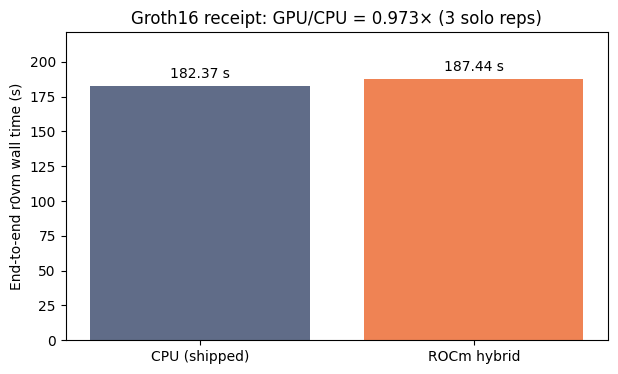

CPU median : 182.37 s
GPU median : 187.44 s
ratio      : 0.973x -> GPU is 2.7% slower end-to-end


In [3]:
medians = rows.groupby("label")["seconds"].median().reindex(["cpu-shipped", "gpu-rocm"])
ratio = medians["cpu-shipped"] / medians["gpu-rocm"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["CPU (shipped)", "ROCm hybrid"], medians.values, color=["#606c88", "#ef8354"])
ax.bar_label(bars, fmt="%.2f s", padding=4)
ax.set_ylabel("End-to-end r0vm wall time (s)")
ax.set_title(f"Groth16 receipt: GPU/CPU = {ratio:.3f}× (3 solo reps)")
ax.set_ylim(0, medians.max() * 1.18)
plt.show()

print(f"CPU median : {medians['cpu-shipped']:.2f} s")
print(f"GPU median : {medians['gpu-rocm']:.2f} s")
print(f"ratio      : {ratio:.3f}x -> GPU is {(1-ratio)*100:.1f}% slower end-to-end")

### Do not call the residual "witness time" (and we did go and measure it later)

At the time, the GPU log only reported the gnark prover's `took=`; it did not separately record `stark_verify` witness, FIFO wait, Docker startup and receipt orchestration. The chart below can therefore only call the leftover time **residual**, and explicitly refuses to treat it as witness time.

That reservation was correct. W0 later added a `CLOCK_MONOTONIC` nanosecond stage timer to `prover.sh`, and the measurement showed that the witness inside the residual is in fact only **1.72 s** — the next section shows the correct decomposition from committed evidence.

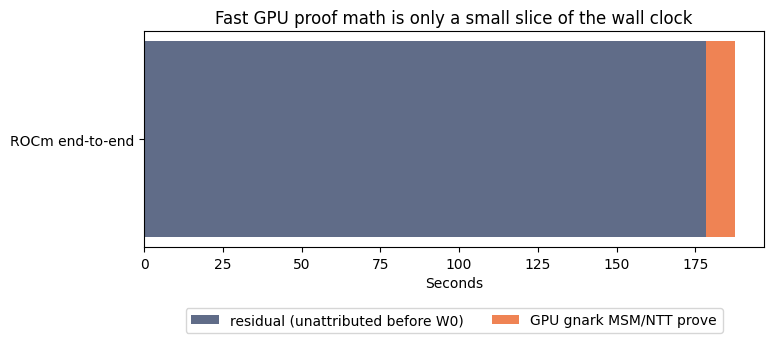

median GPU gnark prove                 : 8.921 s
unattributed residual                  : 178.519 s
CAUTION: this residual is NOT witness time; the next cell shows the W0 measurement.


In [4]:
prove_ms = []
ansi = re.compile(r"\x1b\[[0-9;]*m")
pattern = re.compile(r"prover done.*?took=([0-9.]+)")
for path in sorted(BENCH.glob("bench-gpu-rocm-*.log")):
    clean = ansi.sub("", path.read_text(errors="replace"))
    match = pattern.search(clean)
    if not match:
        raise RuntimeError(f"missing prover timing in {path.name}")
    prove_ms.append(float(match.group(1)))

prove_s = pd.Series(prove_ms).median() / 1000.0
gpu_total = medians["gpu-rocm"]
residual = gpu_total - prove_s

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.barh(["ROCm end-to-end"], [residual], color="#606c88", label="residual (unattributed before W0)")
ax.barh(["ROCm end-to-end"], [prove_s], left=[residual], color="#ef8354", label="GPU gnark MSM/NTT prove")
ax.set_xlabel("Seconds")
ax.set_title("Fast GPU proof math is only a small slice of the wall clock")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=2)
plt.show()

print(f"median GPU gnark prove                 : {prove_s:.3f} s")
print(f"unattributed residual                  : {residual:.3f} s")
print("CAUTION: this residual is NOT witness time; the next cell shows the W0 measurement.")

### W0 measured — the correct stage decomposition

The cell below replays committed witness evidence directly (production FIFO, 3 solo reps, every receipt stock-verified), with no numbers copied by hand.

Two things to note:

1. FIFO runs witness and prover **concurrently**, so `witness_s + prove_s != total_s`; only totals add up.
2. The contents of `.wtns` differ on every execution (r0vm generates a fresh random `identity_p254` seal each time), but the length, the journal and the verification result are fixed.


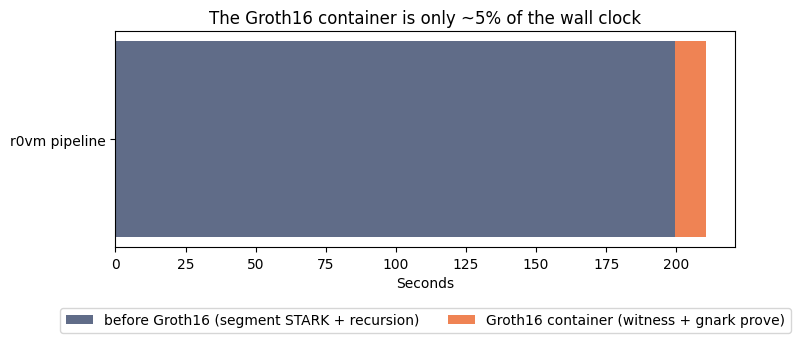

transport                     : fifo
r0vm pipeline median          : 210.592 s
Groth16 container median      : 11.130 s (5.3% of pipeline)
  Circom witness (CPU)        : 1.718 s (0.82% of pipeline)
  gnark prove (iGPU)          : 11.122 s  [overlaps witness via the FIFO]
before Groth16                : 199.462 s (94.7% of pipeline)

Ceiling check: making witness generation instant would save at most 0.82% of end-to-end wall time.


In [5]:
WITNESS = lk.RISC0_ROCM_GROTH16_WITNESS_DIR
w_summary = json.loads((WITNESS / "summary.json").read_text())
w_rows = pd.read_csv(WITNESS / "witness-baseline.csv")

recorded = w_rows[w_rows["phase"] == "recorded"]
assert recorded["solo"].astype(str).str.lower().eq("true").all(), "non-solo witness row"
assert recorded["verified"].astype(str).str.lower().eq("true").all(), "unverified witness row"
assert recorded["journal_sha256"].nunique() == 1, "journal drifted between reps"

o0 = w_summary["modes"]["O0"]
pipeline = o0["r0vm_total_median_s"]
container = o0["total_median_s"]
pre = o0["pre_groth16_median_s"]

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.barh(["r0vm pipeline"], [pre], color="#606c88", label="before Groth16 (segment STARK + recursion)")
ax.barh(["r0vm pipeline"], [container], left=[pre], color="#ef8354", label="Groth16 container (witness + gnark prove)")
ax.set_xlabel("Seconds")
ax.set_title("The Groth16 container is only ~5% of the wall clock")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=2)
plt.show()

print(f"transport                     : {w_summary['witness_mode']}")
print(f"r0vm pipeline median          : {pipeline:.3f} s")
print(f"Groth16 container median      : {container:.3f} s ({o0['groth16_container_share']*100:.1f}% of pipeline)")
print(f"  Circom witness (CPU)        : {o0['witness_median_s']:.3f} s ({o0['witness_median_s']/pipeline*100:.2f}% of pipeline)")
print(f"  gnark prove (iGPU)          : {o0['prove_median_s']:.3f} s  [overlaps witness via the FIFO]")
print(f"before Groth16                : {pre:.3f} s ({pre/pipeline*100:.1f}% of pipeline)")
print("\nCeiling check: making witness generation instant would save at most "
      f"{o0['witness_median_s']/pipeline*100:.2f}% of end-to-end wall time.")


### An overlapping timeline, not a decomposition tree

Under FIFO, witness and prover **run at the same time**, so `witness + prove != total`. Presenting this
as a stack or a tree would be directly misleading. The chart below draws each stage's **start/end
interval** (relative to entrypoint start), and where the intervals overlap, the overlap is real.

`first_payload` marks the moment the first 64 KiB enters the pipeline — this is a producer-side
measurement, because the Go prover issues the syscall directly (LD_PRELOAD cannot intercept it), and
its `/proc` `rchar` is swamped by the loading of the GB-scale proving key.


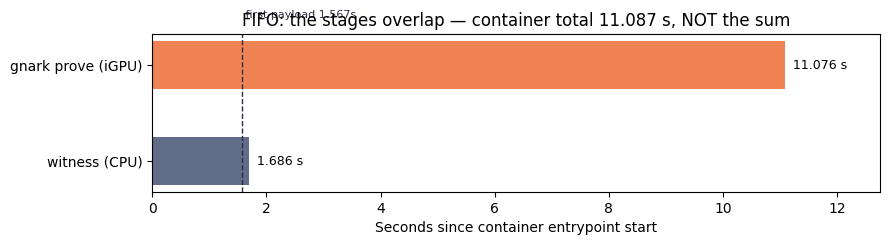

witness span            : 1.686 s
prove span              : 11.076 s
naive sum (WRONG)       : 12.762 s
measured container total: 11.087 s
overlapped region       : 1.685 s


In [6]:
def stage_events(log_path):
    """Stage offsets relative to entrypoint start, parsed from a committed run log."""
    events = {}
    for line in log_path.read_text(errors="replace").splitlines():
        if "[risc0-groth16-stage]" not in line:
            continue
        parts = dict(p.split("=", 1) for p in line.split() if "=" in p)
        if {"stage", "event", "t_ns"} <= parts.keys():
            events[(parts["stage"], parts["event"])] = int(parts["t_ns"])
    base = events[("entrypoint", "start")]
    return {k: (v - base) / 1e9 for k, v in events.items()}

ev = stage_events(lk.RISC0_ROCM_GROTH16_COMPARE_DIR / "rocm-witness-1" / "run.log")
spans = [
    ("witness (CPU)", ev[("witness", "start")], ev[("witness", "finish")], "#606c88"),
    ("gnark prove (iGPU)", ev[("prover", "start")], ev[("prover", "finish")], "#ef8354"),
]
first_payload = ev[("fifo", "first_payload")]
container_total = ev[("total", "finish")]

fig, ax = plt.subplots(figsize=(9, 2.6))
for row, (label, start, end, colour) in enumerate(spans):
    ax.barh(row, end - start, left=start, color=colour, height=0.5)
    ax.text(end + 0.15, row, f"{end - start:.3f} s", va="center", fontsize=9)
ax.axvline(first_payload, color="#2b2d42", linestyle="--", linewidth=1)
ax.text(first_payload, 1.5, f" first payload {first_payload:.3f}s", fontsize=8, color="#2b2d42")
ax.set_yticks(range(len(spans)))
ax.set_yticklabels([s[0] for s in spans])
ax.set_xlabel("Seconds since container entrypoint start")
ax.set_title(f"FIFO: the stages overlap — container total {container_total:.3f} s, NOT the sum")
ax.set_xlim(0, container_total * 1.15)
plt.tight_layout()
plt.show()

witness_span = ev[("witness", "finish")] - ev[("witness", "start")]
prove_span = ev[("prover", "finish")] - ev[("prover", "start")]
overlap = min(ev[("witness", "finish")], ev[("prover", "finish")]) - max(ev[("witness", "start")], ev[("prover", "start")])
print(f"witness span            : {witness_span:.3f} s")
print(f"prove span              : {prove_span:.3f} s")
print(f"naive sum (WRONG)       : {witness_span + prove_span:.3f} s")
print(f"measured container total: {container_total:.3f} s")
print(f"overlapped region       : {max(overlap, 0.0):.3f} s")


### What actually causes 0.973×: same image, same seal, only the accelerator changes

Every inference so far stopped at "what happens inside the container". This section runs the container on
its own, controlled down to a single variable: `RISC0_GROTH16_ACCELERATOR`. `rocm-replay` is the ceiling
control group — the same FIFO, but with the witness replaced by a pre-generated file, removing only the
computation.


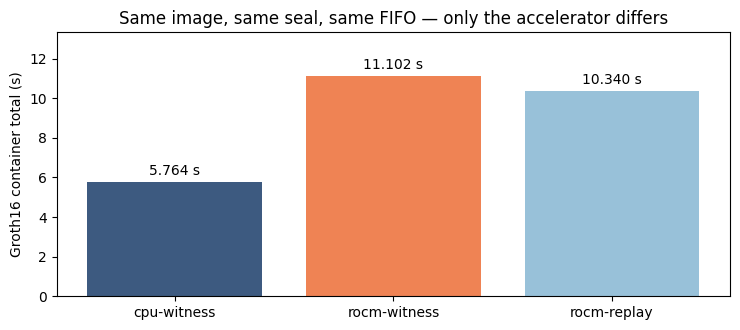

CPU gnark container   : 5.764 s
ROCm gnark container  : 11.102 s
ROCm - CPU            : +5.338 s  (CPU/ROCm = 0.519x)
  -> the published end-to-end gap was CPU 182.37 s vs ROCm 187.44 s = +5.07 s;
     the container difference accounts for it, so 0.973x is NOT witness-bound.

witness ceiling (measured): 0.762 s (11.102 -> 10.340)


In [7]:
COMPARE = lk.RISC0_ROCM_GROTH16_COMPARE_DIR
cmp_summary = json.loads((COMPARE / "summary.json").read_text())
cmp_rows = pd.read_csv(COMPARE / "container-compare.csv")

recorded = cmp_rows[cmp_rows["rep"] != 0]
assert recorded["solo"].astype(str).str.lower().eq("true").all(), "non-solo comparison row"
assert recorded["image_digest"].nunique() == 1, "configs used different images"
assert recorded["input_sha256"].nunique() == 1, "configs used different seals"

order = ["cpu-witness", "rocm-witness", "rocm-replay"]
totals = [cmp_summary["configs"][c]["total_median_s"] for c in order]

fig, ax = plt.subplots(figsize=(7.5, 3.4))
bars = ax.bar(order, totals, color=["#3d5a80", "#ef8354", "#98c1d9"])
ax.bar_label(bars, fmt="%.3f s", padding=3)
ax.set_ylabel("Groth16 container total (s)")
ax.set_title("Same image, same seal, same FIFO — only the accelerator differs")
ax.set_ylim(0, max(totals) * 1.2)
plt.tight_layout()
plt.show()

acc = cmp_summary["accelerator"]
wcp = cmp_summary["witness_critical_path"]
print(f"CPU gnark container   : {acc['cpu_total_median_s']:.3f} s")
print(f"ROCm gnark container  : {acc['rocm_total_median_s']:.3f} s")
print(f"ROCm - CPU            : {acc['rocm_minus_cpu_s']:+.3f} s  (CPU/ROCm = {acc['cpu_over_rocm']:.3f}x)")
print("  -> the published end-to-end gap was CPU 182.37 s vs ROCm 187.44 s = +5.07 s;")
print("     the container difference accounts for it, so 0.973x is NOT witness-bound.")
print()
print(f"witness ceiling (measured): {wcp['measured_saving_s']:.3f} s "
      f"({wcp['with_witness_total_median_s']:.3f} -> {wcp['replayed_witness_total_median_s']:.3f})")


## 2 · Take apart the Circom witness generator

The current production chain:

```text
stark_verify.circom (58 MB LFS)
  -> circom --r1cs --c
  -> stark_verify_cpp/{stark_verify.cpp, *.hpp, stark_verify.dat}
  -> clang++ -O0 -> /usr/local/bin/stark_verify
  -> input.json -> FIFO /tmp/output.wtns
  -> gnark prover (CPU or ROCm MSM/NTT) -> proof.json
```

The first implementation PR should **not touch the 58 MB circuit directly**; add phase timers first, to
obtain separable data:

1. Docker/container startup
2. `stark_verify` process start/end (witness only)
3. FIFO first-byte/last-byte (producer/consumer overlap)
4. gnark parse/constraint solver/prove
5. proof write + receipt orchestration

Then parse the C++ template functions that Circom generates, abstracting each assignment into
`(output signal, opcode, input signals, constants)`. Below is a **small teaching DAG** demonstrating the
schema a production extractor should emit; it does not pretend to have parsed the 58 MB generator.

In [8]:
# Teaching-sized schema for the extractor we would build for generated Circom C++.
ops = pd.DataFrame([
    {"out": "s2", "op": "mul", "inputs": ["s0", "s1"]},
    {"out": "s3", "op": "add", "inputs": ["s2", "k0"]},
    {"out": "s4", "op": "mul", "inputs": ["s2", "s2"]},
    {"out": "s5", "op": "sub", "inputs": ["s4", "s3"]},
    {"out": "s6", "op": "add", "inputs": ["s3", "k1"]},
])

producer = {row.out: i for i, row in ops.iterrows()}
deps = {i: {producer[x] for x in row.inputs if x in producer} for i, row in ops.iterrows()}
levels, remaining = [], set(deps)
while remaining:
    ready = sorted(i for i in remaining if not (deps[i] & remaining))
    if not ready:
        raise ValueError("cycle in witness dependency graph")
    levels.append(ready)
    remaining -= set(ready)

ops["level"] = [next(j for j, level in enumerate(levels) if i in level) for i in ops.index]
print(ops[["out", "op", "inputs", "level"]].to_string(index=False))
print("\nOperation counts:")
print(ops.groupby(["level", "op"]).size().rename("count"))
print("\nGPU work queues (one queue per dependency level):")
for level, ids in enumerate(levels):
    print(f"  level {level}: {ops.loc[ids, 'out'].tolist()}")

out  op   inputs  level
 s2 mul [s0, s1]      0
 s3 add [s2, k0]      1
 s4 mul [s2, s2]      1
 s5 sub [s4, s3]      2
 s6 add [s3, k1]      2

Operation counts:
level  op 
0      mul    1
1      add    1
       mul    1
2      add    1
       sub    1
Name: count, dtype: int64

GPU work queues (one queue per dependency level):
  level 0: ['s2']
  level 1: ['s3', 's4']
  level 2: ['s5', 's6']


## 3–6 · From a BN254 field kernel to a full GPU witness

### W0 — get a real baseline first ✅ done (2026-07-29)

What was done: `prover.sh` gained a `CLOCK_MONOTONIC` nanosecond stage timer, a dual
`RISC0_GROTH16_WITNESS_MODE=fifo|file` transport, a `RISC0_WITGEN_OPT_LEVEL` build arg, and a baseline runner that is solo-guarded, interleaved and warm-up excluded.

What was measured:

- Circom witness **1.718 s**; Groth16 container total **11.130 s**; r0vm pipeline **210.592 s**.
- witness is only **0.8%** of the pipeline, and the container as a whole is **5.3%**.

**Negative result from the compiler baseline**: `stark_verify.cpp` is generated by circom from `stark_verify.circom`, a **58 MB** Git LFS object (recorded in `groth16-seam-validation.md`); compiling it with `-O2` ran for **106,093 seconds** — **29.5 hours**, derived from that figure rather than logged — **without finishing**: the build log records `make: *** [Makefile:24: stark_verify.o] Killed` at that timestamp. It does not record why the process was killed, so no cause is claimed here. `-O0` takes only **245.5 seconds**. This is the empirical reason the upstream Dockerfile deliberately forces `-O0`. **O2 is recorded as measured infeasible; O3 was never run** (the run was aborted at O2), so we make no claim about O3 — only that it is not expected to be cheaper than O2. Bounded builds will record this automatically in future.

> **How to check it**: both runs are archived in `groth16-witness-gfx1151-20260727T130143Z/` — the `106093.0 ... Killed` line is line 1148 of `build-o2.log`, `DONE 245.5s` is line 1151 of `build-o0.log`, and `provenance.txt` carries the start time and the commit. One thing to expect when reading them: the opt level under test is appended after the `-O3` already in `$(CFLAGS)`, so the compile line reads `-std=c++11 -O3 -I. -O2` (or `-O0`) and the trailing flag is the one that applies. The three small translation units beside it do build at `-O3`, in about two seconds either way, which is why the claim above is about `stark_verify.cpp` alone.

### ⚠️ The investment case for W1–W4 has been refuted by W0

W1–W4 below (GPU witness generation, originally estimated at 4–8 weeks) were planned under the assumption that "witness dominates wall clock". The W0 measurement shows that assumption does not hold:

> Even if witness generation became **entirely free**, end-to-end would only be **0.8%** faster.

The W1–W4 material below is therefore **retained as technical reference and teaching material**, but it is **no longer the next step for performance**. The real bottleneck is the **199.5 s (94.7%)** ahead of the Groth16 container: rv32im segment STARK proving and recursion lift/join/identity_p254.

That is itself the most important lesson of this lab: **measuring before investing can save weeks of engineering aimed in the wrong direction.**

### W1 — finite field GPU core (3–7 days)

Using the existing `libzkp_hip.so`/BN254 Montgomery layout, add a standalone C ABI:

```c
int bn254_witness_batch_add(const uint64_t* a, const uint64_t* b, uint64_t* out, size_t n);
int bn254_witness_batch_mul(const uint64_t* a, const uint64_t* b, uint64_t* out, size_t n);
```

Test add/sub/mul/Montgomery reduction on random + edge vectors first, element-for-element identical to CPU. Do not touch the full circuit yet.

### W2 — Witness DAG and level-based scheduling (1–2 weeks)

- The parser emits `op, out, in0, in1, const_idx, level` SoA arrays.
- After a topological sort, build GPU queues by dependency level; work within one level runs in parallel.
- Port the most frequently repeated opcodes first; unsupported templates/functions must **fail closed or fall back to CPU**, never silently skip.

### W3 — Memory layout (3–7 days)

| axis | first implementation | experiment |
|---|---|---|
| signals | SoA contiguous Montgomery limbs | AoS vs SoA |
| constants | immutable device buffer | constant/L2 cache |
| queues | preallocated op/index arrays | queue compaction |
| handoff | managed memory on this APU | pinned host vs managed |
| launches | one/few kernels per level bucket | fuse small adjacent levels |

The first APU version should prefer managed/unified memory, to avoid forcing discrete-GPU H2D assumptions onto Strix Halo; bytes moved, kernel count, coalescing and occupancy still have to be recorded.

### W4 — Runtime integration (1–2 weeks)

The least invasive route: keep the `prover.sh` FIFO contract and add a `stark_verify_hip` that produces **exactly the same `.wtns` bytes**. Only once that is stable should direct-memory handoff to gnark be considered, so that the witness and prover boundaries are not changed at the same time.

API options: C ABI (smallest), pybind11 (convenient for teaching), subprocess (most isolated). For production we recommend C ABI + subprocess fail isolation, with any CPU fallback recorded explicitly.

## 7 · Witness and proof correctness gates

Every stage must clear correctness before speed is discussed at all:

1. **Field vectors** — CPU/GPU add/sub/mul/Montgomery, random + `{0,1,p-1}`.
2. **Small Circom circuits** — `.wtns` header, section lengths, and every field element equal one by one.
3. **`stark_verify` full input** — CPU/GPU `.wtns` byte-identical; if the format permits non-canonical encoding, canonicalize first, then compare element by element while retaining the original hash.
4. **Constraint satisfaction** — all constraints pass on the same R1CS; public inputs identical.
5. **Groth16 native verify** — proof accepted.
6. **RISC0 receipt** — journal byte-identical, stock `cargo risczero verify` accepted.
7. **On-chain** — existing `verifyStep -> true`.
8. **Fail closed** — no HIP device/library/unsupported opcode must error or explicitly select CPU; never silently return a partial witness.

Only once 1–8 are all green does the solo benchmark run.

In [9]:
# The comparison contract the future GPU witness gate should implement.
def compare_witness(cpu_words, gpu_words):
    if len(cpu_words) != len(gpu_words):
        return {"ok": False, "reason": "length mismatch", "cpu_n": len(cpu_words), "gpu_n": len(gpu_words)}
    mismatches = [i for i, (a, b) in enumerate(zip(cpu_words, gpu_words)) if a != b]
    return {
        "ok": not mismatches,
        "elements": len(cpu_words),
        "mismatch_count": len(mismatches),
        "first_mismatches": mismatches[:10],
    }

# Teaching smoke check; production inputs come from parsed canonical .wtns sections.
print(compare_witness([0, 1, 7, 42], [0, 1, 7, 42]))
print(compare_witness([0, 1, 7, 42], [0, 1, 8, 42]))

{'ok': True, 'elements': 4, 'mismatch_count': 0, 'first_mismatches': []}
{'ok': False, 'elements': 4, 'mismatch_count': 1, 'first_mismatches': [2]}


## 8 · STARK `eval_check`: launch tuning is proven ineffective

We actually swept the recursion `eval_check` block size over 64/128/256/512, 3 reps each. The conclusion
is not "keep guessing at block sizes": rocprofv3 shows **192 VGPR/thread at every block size**, so the
kernel is register-bound, and the original block=256 was already the fastest. The experimental knob has
been withdrawn and the production kernel is unchanged.

Kernel-level experiments with a genuine chance in the next round:

1. compiler register report + ISA inspection, to locate the longest live ranges;
2. kernel splitting (trading lower occupancy for exchange through an intermediate buffer);
3. recompute-vs-cache, to shorten temporary lifetimes;
4. SoA/constant table layout, to reduce address/value temporaries;
5. `__launch_bounds__` / compiler flags, experimented with only after the correctness gate;
6. run GPU==CPU on every version first, then measure at production-size domain.

The launch block negative result is itself a deliverable: it stops the team from wasting more time on the
wrong tuning axis.

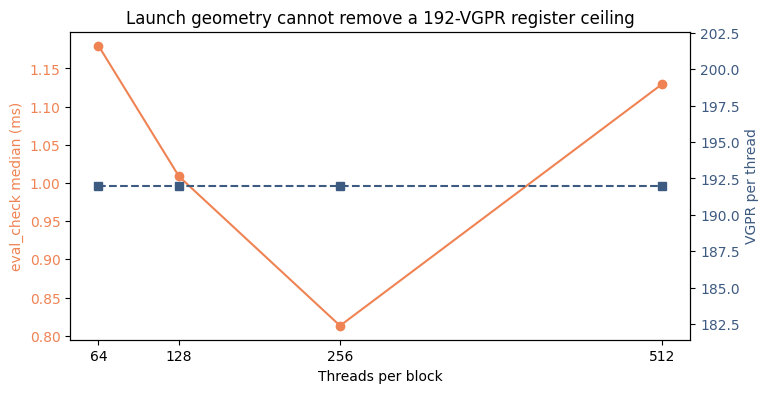

 block  median_ns  min_ns  max_ns  reps  vgpr  scratch_bytes
    64    1179782  811607 1180432     3   192           3824
   128    1008614  822665 1034153     3   192           3824
   256     813134  812971 1215411     3   192           3824
   512    1129530  931956 1146607     3   192           3824

Best block = 256 (the existing default); VGPR/thread is constant at 192.
Result: evidence-backed negative; experimental code reverted.


In [10]:
sweep = pd.read_csv(TUNING / "block-sweep-summary.csv")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sweep["block"], sweep["median_ns"] / 1e6, marker="o", color="#ef8354", label="kernel median")
ax.set_xlabel("Threads per block")
ax.set_ylabel("eval_check median (ms)", color="#ef8354")
ax.tick_params(axis="y", labelcolor="#ef8354")
ax.set_xticks(sweep["block"])

ax2 = ax.twinx()
ax2.plot(sweep["block"], sweep["vgpr"], marker="s", linestyle="--", color="#3d5a80", label="VGPR/thread")
ax2.set_ylabel("VGPR per thread", color="#3d5a80")
ax2.tick_params(axis="y", labelcolor="#3d5a80")
ax.set_title("Launch geometry cannot remove a 192-VGPR register ceiling")
plt.show()

best = sweep.loc[sweep["median_ns"].idxmin()]
print(sweep.to_string(index=False))
print(f"\nBest block = {int(best.block)} (the existing default); VGPR/thread is constant at {sweep.vgpr.nunique() == 1 and int(best.vgpr)}.")
print("Result: evidence-backed negative; experimental code reverted.")

## 9 · Build reproducible performance experiments

Every row of a future GPU witness benchmark should contain at least:

```text
commit, image_digest, compiler, opt_level, circuit_sha256, constraints,
mode, rep, witness_s, fifo_wait_s, prove_s, verify_s, total_s,
gpu_busy_pct, loadavg, solo, wtns_sha256, receipt_sha256, verified
```

Rules: warm-ups do not count; ≥3 solo reps per config; interleave modes to reduce thermal/order bias; keep median plus min/max in full; reject any non-solo or unverified row from the summary.

### Resource estimate

- **Prototype / small circuits:** 1–2 weeks; gfx1151, 16–32 GB RAM, 20 GB disk.
- **Full `stark_verify` GPU witness:** roughly **4–8 weeks** (1 engineer fluent in HIP/Circom); 32 CPU threads, gfx1151, **32–64 GB RAM**, **40–60 GB disk**.
- Main risks: generated control flow, cross-template dependencies, field canonicalization, GPU queues that are too fragmented, and `.wtns` streaming handoff.

### Heavy rerun (do not run during replay)

```bash
# Existing verified end-to-end benchmark (solo-guarded)
RISC0_GROTH16_VALIDATION_GATES=I_UNDERSTAND_GPU_MUST_BE_IDLE \
RISC0_GROTH16_RUN_BENCHMARK=1 RISC0_HIP_OFFLOAD_ARCH=gfx1151 \
bash poc/risc0-rocm-prover/groth16-seam/scripts/run-gates.sh

# Future witness experiment: explicitly gated; never default notebook behavior
LAB_RUN_HEAVY=1 RISC0_GROTH16_WITNESS_BACKEND=rocm \
bash poc/risc0-rocm-prover/groth16-seam/scripts/run-witness-gates.sh
```

The second command is a roadmap interface and is not yet implemented; it must not be created until W0–W4 have landed.

## 10 · Incremental GPU offload labs (suggested follow-on sessions)

| Lab | what can be run | correctness gate | performance target |
|---|---|---|---|
| 24A · BN254 batch field | HIP add/sub/mul/Montgomery + C ABI | random/edge vectors GPU==CPU | ≥5× CPU scalar throughput at large batch |
| 24B · Witness DAG | parser + topological levels + work queues | deterministic schedule, no cycles | report parallel width / launch count |
| 24C · GPU witness integration | small Circom then `stark_verify_hip` | `.wtns` element/byte equality | reduce measured witness stage ≥2× |
| 24D · eval_check registers | split/recompute/live-range experiments | GPU==CPU | ≥5% production kernel improvement |
| 24E · end-to-end | receipt + journal + stock + on-chain verify | all gates PASS | move total wall, not only kernel time |

This notebook is the "24 · bottleneck forensics" overview; the labs above can be split into 24A–24E once the implementation is mature. For now a single Lab 24 is kept, so that a production GPU witness that is not finished is not packaged as finished teaching material.

## 11 · Generate the workshop experiment report automatically

Labs and the workshop should read the same committed CSV/JSON directly, rather than copying numbers by hand. CI can:

1. verify the evidence SHA-256;
2. reject `solo=false` / `verified=false`;
3. generate Markdown tables and charts from the JSON/CSV;
4. compare the workshop summary against the artefact summary to prevent drift;
5. preserve hardware / ROCm / compiler / image digest metadata.

The cell below produces Markdown that can be pasted into the workshop, while still clearly separating capability from speed.

In [11]:
cpu = summary["modes"]["cpu-shipped"]
gpu = summary["modes"]["gpu-rocm"]
report = f"""### RISC0 Groth16 ROCm — same-box benchmark

| mode | reps | min (s) | median (s) | max (s) |
|---|---:|---:|---:|---:|
| CPU shipped | {cpu['count']} | {cpu['min_s']:.2f} | {cpu['median_s']:.2f} | {cpu['max_s']:.2f} |
| ROCm hybrid | {gpu['count']} | {gpu['min_s']:.2f} | {gpu['median_s']:.2f} | {gpu['max_s']:.2f} |

- End-to-end GPU/CPU: **{ratio:.3f}×** (GPU is {(1-ratio)*100:.1f}% slower).
- GPU gnark BN254 prove: **~{prove_s:.1f} s**; unattributed residual at the time: **~{residual:.1f} s**.
- W0 measured (production FIFO, 3 solo reps): Circom witness **{o0['witness_median_s']:.2f} s**, Groth16 container **{container:.2f} s** = **{o0['groth16_container_share']*100:.1f}%** of the **{pipeline:.1f} s** pipeline; the remaining **{pre:.1f} s** is segment STARK + recursion, not witness.
- Capability: MSM/NTT run on iGPU and every receipt stock-verifies.
- Scope: hybrid, same-box, workload-specific; not pure GPU and not cross-vendor.
"""
print(report)

### RISC0 Groth16 ROCm — same-box benchmark

| mode | reps | min (s) | median (s) | max (s) |
|---|---:|---:|---:|---:|
| CPU shipped | 3 | 181.90 | 182.37 | 182.42 |
| ROCm hybrid | 3 | 186.66 | 187.44 | 187.53 |

- End-to-end GPU/CPU: **0.973×** (GPU is 2.7% slower).
- GPU gnark BN254 prove: **~8.9 s**; unattributed residual at the time: **~178.5 s**.
- W0 measured (production FIFO, 3 solo reps): Circom witness **1.72 s**, Groth16 container **11.13 s** = **5.3%** of the **210.6 s** pipeline; the remaining **199.5 s** is segment STARK + recursion, not witness.
- Capability: MSM/NTT run on iGPU and every receipt stock-verifies.
- Scope: hybrid, same-box, workload-specific; not pure GPU and not cross-vendor.



## Takeaways

1. **Measure before you invest.** "The residual is mostly CPU witness" was a reasonable assumption, and it was wrong. W0 measured the witness at only **1.72 s / 0.8%**, which cancelled outright a GPU witness project originally estimated at **4–8 weeks**. One 20-minute measurement replaced weeks of misdirected investment.
2. **Kernel speed ≠ end-to-end speed, but you still have to point at the right bottleneck.** **95–97%** of the full pipeline (session dependent) sits in the segment STARK and recursion ahead of Groth16; the Groth16 container as a whole is only **5.3%**.
3. **A compiler baseline can also be a negative result.** Compiling the witness with `-O2` had not finished after 29.5 hours, while `-O0` takes only 245 seconds — there is a reason upstream forces `-O0`.
4. **Read the implementation before discussing architecture.** "The GPU is slower" was first guessed to be
   a bandwidth problem, then an ISA problem; the answer was finally found in the kernel source: the port's
   source is missing two standard MSM optimizations. Architectural speculation consumed two rounds, and
   one `grep` settled it.
5. **Design hypotheses so that a single experiment can kill them.** The ISA hypothesis could not be
   settled by argument, but a bare multiplication microbenchmark with no point arithmetic executed it in
   ten minutes — the GPU is in fact 2.41× faster. **Only a killable hypothesis is worth anything.**
6. **Measurement precision determines what may be claimed.** Container-level variation is < 0.7%,
   end-to-end 13%. From the same data, one level can publish a precise value and the other can only
   discuss attribution.
7. **Negative results are deliverables.** The block-size sweep proved `eval_check` is 192-VGPR register-bound, which avoids continuing to turn the wrong knob.
8. **Correctness gates precede benchmarks.** `.wtns`, constraint, proof, receipt, journal, stock verify and on-chain must all hold, layer by layer.
9. **Teach the process, not only the win.** What is most worth teaching from this work is how to get from capability success to honest parity, and then identify the real next engineering target.